In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
import warnings

from util import load_experiment, random_quantiles

In [2]:
warnings.filterwarnings("ignore")

In [3]:
# model_12hr, dataset, config = load_experiment('9e261057-b3c0-4cd9-81ed-d902d1b6b9f7', '../../data/processed/dataset_clean_no-outliers.csv')
# model_12hr_ar, _, _, = load_experiment('ae3cd9a0-d0e6-4118-8a69-44b6ce37fad8', '../../data/processed/dataset_clean_no-outliers.csv', use_autoregressive=True)
# model_24hr_ar, _, _, = load_experiment('f3c623f8-a28d-457c-97af-00ac3cfadd27', '../../data/processed/dataset_clean_no-outliers.csv', use_autoregressive=True)

model_12hr, dataset, config = load_experiment('1af14316-6d67-4227-8108-3dbb35d40941', '../../data/processed/dataset_2018-21_withloads_power.csv', use_autoregressive=True)
model_24hr, _, _ = load_experiment('9bc9de52-1d8e-49de-91a6-32a467b54265', '../../data/processed/dataset_2018-21_withloads_power.csv', use_autoregressive=True)
model_168hr, _, _ = load_experiment('2ca44ffe-371f-4648-92f7-3cfcbd5b4f25', '../../data/processed/dataset_2018-21_withloads_power.csv', use_autoregressive=True)

Time steps to predict: 24
[ 0.35565764  0.4207449   0.4094128   0.20784967  0.35165325  0.3868165
  0.28235537  0.32278502  0.05932401  0.032086    0.0391776   0.09931812
  0.05515771  0.11149877  0.09238018 -0.0554795   0.14292824  0.00283232
  0.04898143  0.02179246 -0.06233546 -0.0537827  -0.02390149  0.1701864 ]


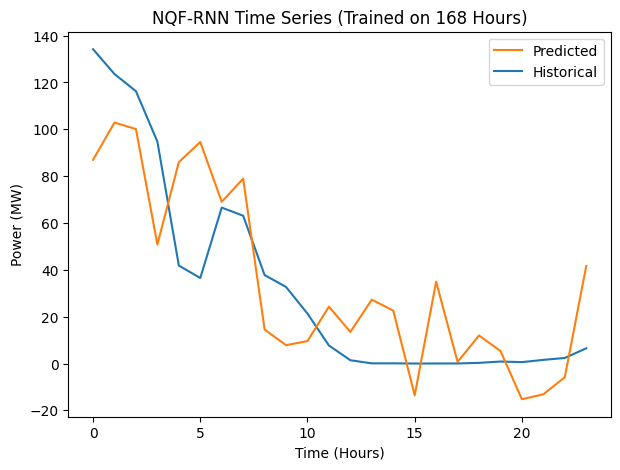

Time steps to predict: 48
[ 0.32421517  0.42238423  0.44289902  0.42040643  0.2783028   0.3393834
  0.19667399  0.01114726  0.08347598  0.18126334  0.04725584 -0.02685484
  0.00517923  0.09251958  0.15976131 -0.07721874  0.05833638  0.01448962
  0.02933589 -0.0279896   0.12402549 -0.06116524  0.04496562 -0.0689469
  0.0486269   0.14134207  0.1397992   0.11348243  0.10130981  0.00937429
  0.08716485  0.04532607  0.05514833  0.10440463  0.07147025  0.19380298
  0.2486797  -0.06208098  0.14622335 -0.12074026  0.02911052 -0.08352929
 -0.07919434 -0.00842185  0.09359619  0.07302263  0.21134344  0.27943528]


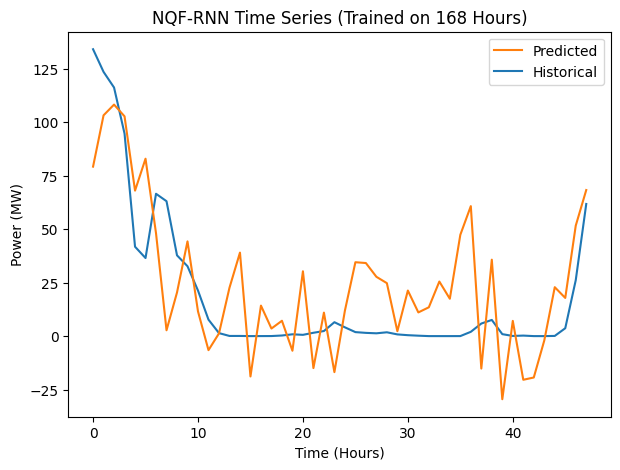

Time steps to predict: 168
[ 4.82941806e-01  3.66747558e-01  4.36822772e-01  1.88804865e-01
  2.61831462e-01  3.33618939e-01  1.15554430e-01  3.73384356e-03
  7.83032477e-02  1.80955529e-02 -1.25823915e-02  3.52858454e-02
  8.62549543e-02  4.73210067e-02  3.15821320e-02 -1.40371621e-02
 -5.63778281e-02  8.73706639e-02 -2.97066271e-02 -6.63724840e-02
 -2.71038115e-02 -8.45802724e-02 -3.68180871e-03  6.97252154e-02
  2.21920788e-01 -3.68254781e-02  3.00243497e-04  1.23739272e-01
  5.69427609e-02  4.52932119e-02 -5.03483415e-03  1.49214566e-02
  1.32644236e-01  1.36508629e-01  9.51945633e-02  1.75749362e-01
  1.17279246e-01  4.27870601e-02  2.14091241e-02  8.31457675e-02
  2.98384428e-02  1.38960078e-01  9.49527323e-03  5.10745347e-02
  8.34641904e-02 -6.27267361e-03  2.92761177e-01  1.89944819e-01
  5.39600492e-01  4.26871151e-01  5.27347684e-01  4.28573161e-01
  3.77864301e-01  5.56908011e-01  6.72761440e-01  6.21321082e-01
  6.12550318e-01  3.88850510e-01  1.63430423e-01  1.20992139e-0

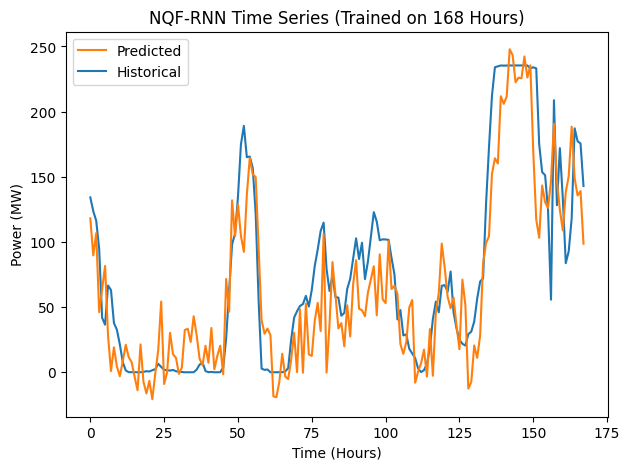

Time steps to predict: 720
[ 0.4686548   0.49160424  0.36969498  0.12299301  0.26060152  0.35008353
  0.30736545  0.23506054  0.32265094  0.2766385   0.10359168  0.20171282
  0.09363067  0.08338818 -0.09378108 -0.05647847 -0.07266605 -0.08308402
 -0.11149216  0.1358425   0.06373599 -0.08036953  0.05409047 -0.04057971
  0.10221455  0.21005443 -0.05598208  0.11497223  0.09883061  0.12338209
  0.15886839  0.19879234  0.1124485   0.1334588   0.1542241   0.01799268
  0.01042365  0.1747343   0.08919308 -0.02722341 -0.11234131  0.01575033
 -0.14356974  0.07047905  0.15320356  0.05797753  0.23770458  0.43750137
  0.5752984   0.5038755   0.5943179   0.43651286  0.54000133  0.5028924
  0.65988207  0.72733706  0.6746117   0.62759984  0.11311765  0.11300524
  0.11915937  0.02573457  0.1249606   0.04004949 -0.02495456  0.26517797
 -0.00128676  0.00609665  0.180107    0.15519318  0.14456725  0.19158287
  0.17262547  0.14873707  0.30893323  0.26431665  0.3225666   0.38676482
  0.37500048  0.28302926 

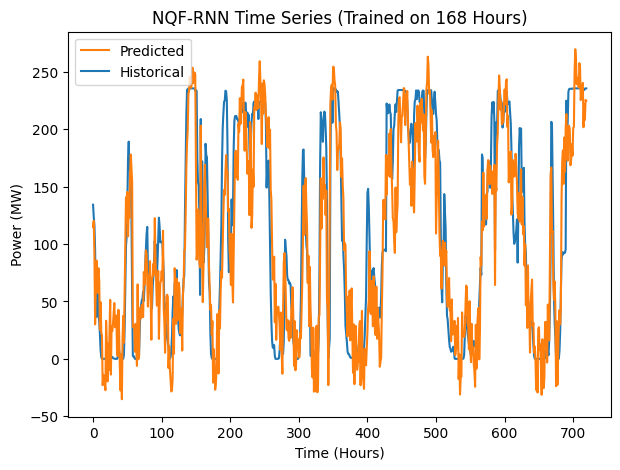

Time steps to predict: 200
[ 0.33474806  0.2791639   0.34107345  0.23449995  0.24918889  0.27595162
  0.37255573  0.3186972   0.10166097  0.01691996  0.17492285 -0.00421809
 -0.03928509 -0.01754218 -0.08775046  0.00790377  0.09192722  0.09914893
  0.03671192  0.06047732 -0.00210312  0.07237127  0.09017134 -0.0036363
  0.09388916  0.05879787  0.11634953  0.04260613  0.11605375 -0.05176559
 -0.07796732  0.01158631 -0.02914983 -0.04428199 -0.10981372 -0.09648067
 -0.06352684  0.10313231  0.13094857  0.01118219  0.15727884  0.06086251
  0.06637394 -0.10192674  0.17816871  0.03985454  0.14577793  0.37011635
  0.49337277  0.5564264   0.5876905   0.41515708  0.3877809   0.49366266
  0.47923312  0.6875876   0.7464094   0.46798682  0.21655072  0.0577569
 -0.0315828  -0.09183052 -0.04693431  0.06683792  0.00606552  0.05567747
  0.07101411 -0.04994205 -0.08140042  0.0395624   0.21037757  0.00946125
 -0.00336045  0.21635753  0.2730484   0.25322783  0.21945162  0.12375685
  0.2924185   0.25805253  

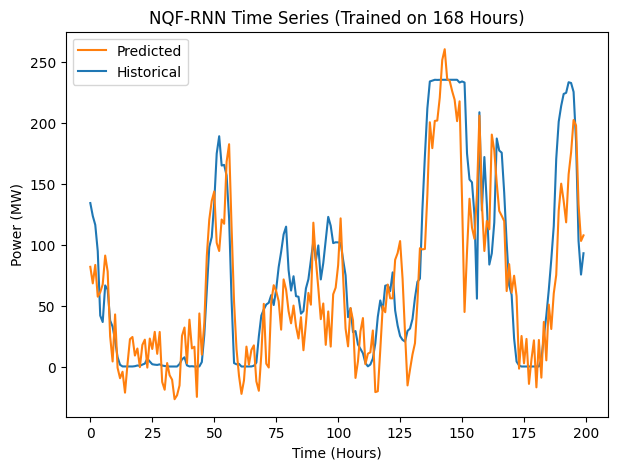

In [8]:
(speed, power) = dataset

# models = [model_12hr, 
#           model_24hr, 
#           model_48hr, 
#           model_72hr, 
#           model_96hr, 
#           model_120hr, 
#           model_144hr,
#           model_168hr]
models = [model_168hr]
# model_labels = [12, 24, 48, 72, 96, 120, 144, 168]
model_labels = ['Predicted']

# scales = ['1 day', '2 days', '1 week', '1 month']
scales = ['1 day', '2 days', '1 week', '1 month', '200 hours']
upper_bounds = [24, 24 * 2, 24 * 7, 24 * 30, 200]

M = len(models)

for i in range(len(scales)):
    scale = scales[i]
    T = upper_bounds[i]
    x = np.arange(0, T)

    input = speed[:T].unsqueeze(0)
    target = power[:T]

    norm_speed = input.squeeze() / torch.max(input)
    cmap = plt.get_cmap('YlOrRd', M + 2)
    print(f'Time steps to predict: {T}')
    # Use same quantiles for all models to ensure "fairness" in visualizing predictions

    plt.figure(figsize=(7, 5))

    quantiles = random_quantiles(size=(T), low=0.01, high=0.99)
    for j in range(M):
        model = models[j]
        label = model_labels[j]
        predicted_power = model(input, quantiles).detach().cpu().numpy().squeeze()
        print(predicted_power)
        plt.plot(x, predicted_power * 244.5, label=f'{label}', color='tab:orange')

    plt.plot(x, target * 244.5, label='Historical', color='tab:blue', zorder=0)
    # plt.plot(x, norm_speed, '--b', label='Wind Speeds (Normalized)')

    plt.title(f'NQF-RNN Time Series (Trained on 168 Hours)')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Power (MW)')
    plt.legend()
    plt.show()

[]

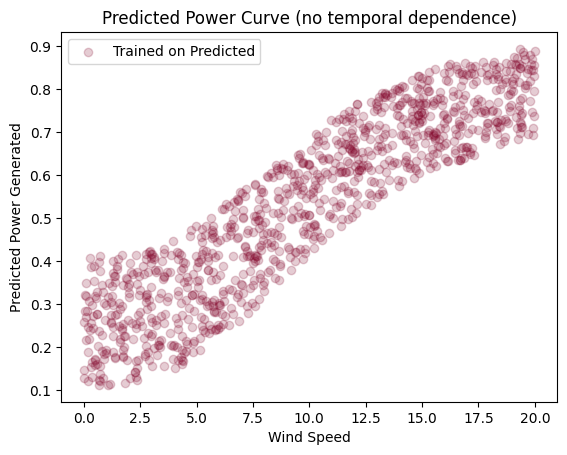

In [5]:
N = 1000
random_wind_speeds = np.random.uniform(0, 20, N)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    preds = []
    cmap = plt.get_cmap('YlOrRd', M + 2)

    for speed in random_wind_speeds:
        input = torch.tensor([speed], dtype=torch.float).unsqueeze(0)
        alpha = random_quantiles(1, 0.01, 0.99)
        pred = model(input, alpha).detach().cpu().numpy().squeeze()
        preds.append(pred)
    plt.scatter(random_wind_speeds, preds, alpha=0.2, color=cmap(i+2), label=f'Trained on {label}')
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (no temporal dependence)')
plt.legend()
plt.plot()

[]

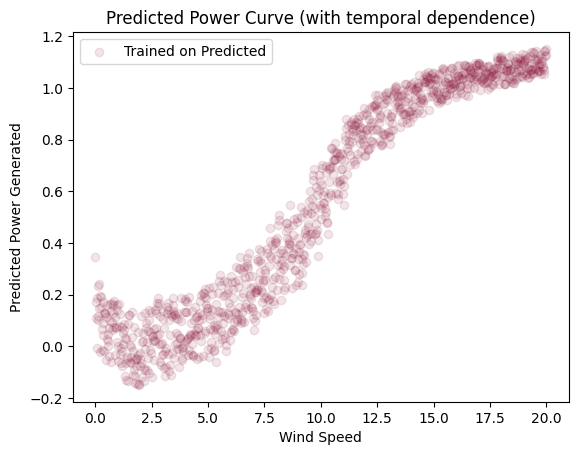

In [6]:
N = 1000
random_wind_speeds = np.linspace(0, 20, N)
cmap = plt.get_cmap('YlOrRd', M + 2)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    input = torch.tensor(random_wind_speeds, dtype=torch.float).unsqueeze(0)
    alpha = random_quantiles(N, 0.01, 0.99)
    preds = model(input, alpha).detach().cpu().numpy().squeeze()
    plt.scatter(random_wind_speeds, preds, alpha=0.1, color=cmap(i+2), label=f"Trained on {label}")
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (with temporal dependence)')
plt.legend()
plt.plot()

[]

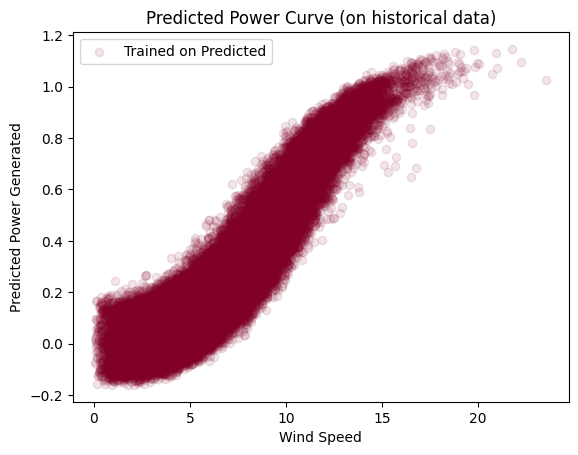

In [9]:
cmap = plt.get_cmap('YlOrRd', M + 2)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
    alpha = random_quantiles(len(speed), 0.01, 0.99)
    preds = model(input, alpha).detach().cpu().numpy().squeeze()
    plt.scatter(speed, preds, alpha=0.1, color=cmap(i+2), label=f"Trained on {label}")
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (on historical data)')
plt.legend()
plt.plot()

[]

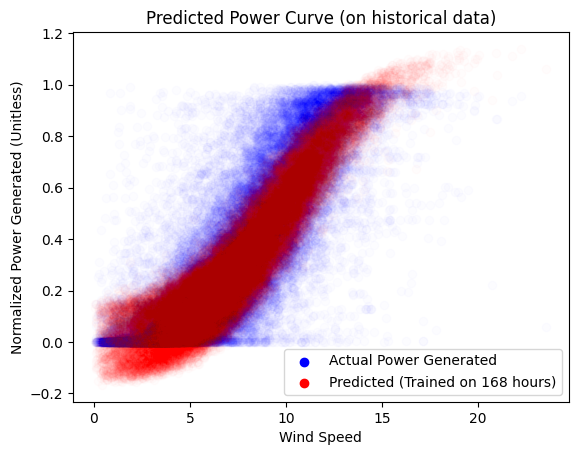

In [10]:
from matplotlib.collections import PathCollection
from matplotlib.legend_handler import HandlerPathCollection, HandlerLine2D

cmap = plt.get_cmap('YlOrRd', M + 2)

model = model_168hr
input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
alpha = random_quantiles(len(speed), 0.01, 0.99)
preds = model(input, alpha).detach().cpu().numpy().squeeze()

plt.scatter(speed, power, alpha=0.01, color='b', label=f"Actual Power Generated")
plt.scatter(speed, preds, alpha=0.01, color='r', label=f"Predicted (Trained on 168 hours)")
plt.ylabel('Normalized Power Generated (Unitless)')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (on historical data)')

def update(handle, orig):
    handle.update_from(orig)
    handle.set_alpha(1)

plt.legend(handler_map={PathCollection : HandlerPathCollection(update_func= update),
                        plt.Line2D : HandlerLine2D(update_func = update)})
plt.plot()

## presentation graphs

In [11]:
df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'lmp', 'user_load_zonal'])
df.rename({'speed_HRRR': 'speed', 'ercot_power': 'power'}, axis=1, inplace=True)

# normalize power and speed
df['npower'] = df['power'] / df['power'].max()
df['nspeed'] = (df['speed'] - df['speed'].min()) / (df['speed'].max() - df['speed'].min())

In [15]:
model = model_168hr # model_12hr, model_24hr, model_168hr
input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
alpha = random_quantiles(len(speed), 0.01, 0.99)
npreds = model(input, alpha).detach().cpu().numpy().squeeze()
preds = npreds * 244.5

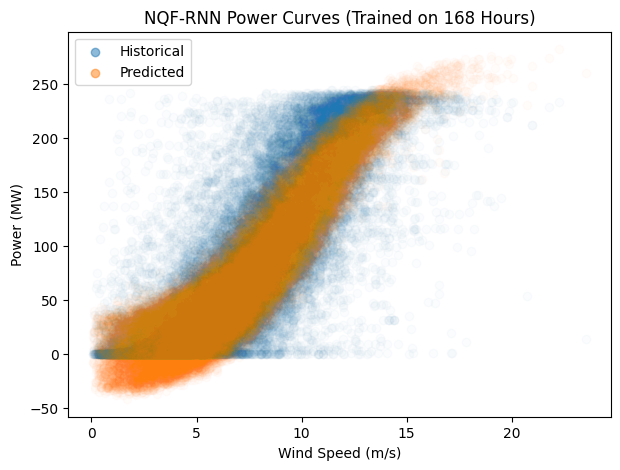

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(df['speed'], df['power'], alpha=0.02, label='Historical')
plt.scatter(df['speed'], preds, alpha=0.02, label='Predicted')

plt.ylabel('Power (MW)')
plt.xlabel('Wind Speed (m/s)')
plt.title('NQF-RNN Power Curves (Trained on 168 Hours)')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)
leg.legend_handles[1].set_alpha(0.5)

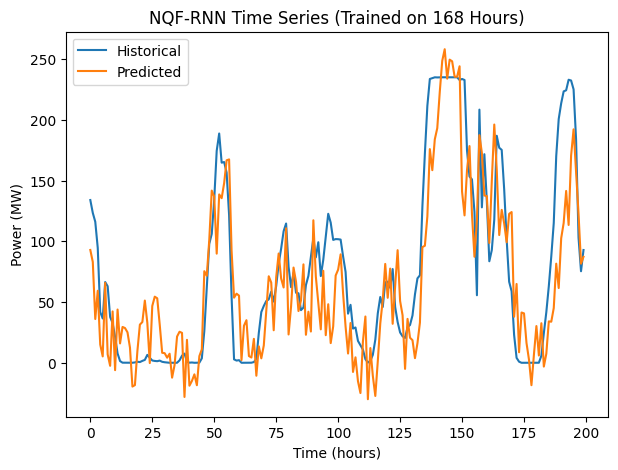

In [17]:
plt.figure(figsize=(7, 5))
plt.plot(df['power'][:200], label='Historical')
plt.plot(preds[:200], label='Predicted')
plt.title('NQF-RNN Time Series (Trained on 168 Hours)')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

In [19]:
from sklearn.metrics import mean_squared_error

In [20]:
print(mean_squared_error(df['npower'], npreds))
print(mean_squared_error(df['power'], preds))

0.03978712935513114
2373.473406642308


## save csv for we-validate

In [39]:
from datetime import datetime, timedelta

In [108]:
df['preds'] = preds
df['npreds'] = npreds

In [109]:
df

,datetime,speed,power_cf,power,npower,nspeed,preds,npreds
0,2018-01-01 01:00:00,6.384246,0.191033,134.039,0.548825,0.268745,119.736473,0.489720
1,2018-01-01 02:00:00,6.679563,0.220842,123.450,0.505468,0.281334,94.574844,0.386809
2,2018-01-01 03:00:00,6.784414,0.232067,116.143,0.475550,0.285803,94.784836,0.387668
3,2018-01-01 04:00:00,6.794198,0.233133,94.625,0.387444,0.286221,38.709515,0.158321
4,2018-01-01 05:00:00,7.114358,0.269688,41.765,0.171008,0.299868,26.089851,0.106707
...,...,...,...,...,...,...,...,...
34851,2021-12-31 13:00:00,2.544705,0.000000,5.338,0.021857,0.105072,25.710924,0.105157
34852,2021-12-31 14:00:00,2.059370,0.000000,6.463,0.026463,0.084383,-8.147799,-0.033324
34853,2021-12-31 15:00:00,3.659931,0.024277,10.312,0.042223,0.152612,-3.748298,-0.015330
34854,2021-12-31 16:00:00,4.747566,0.070125,16.813,0.068841,0.198976,3.389787,0.013864


In [110]:
df.rename(columns={'datetime': 'time_stamp'}, inplace=True)

In [111]:
# generate time_stamps in order for we-validate compatibility
def generate_time_stamps(start_date):
    current = start_date
    time_stamps = []
    while len(time_stamps) < 34856:
        time_stamps.append(current.strftime('%Y-%m-%d %H:%M:%S'))
        current += timedelta(hours=1)
    return time_stamps

time_stamp = generate_time_stamps(datetime(2018, 1, 1, 1, 0, 0))
df['time_stamp'] = time_stamp

In [112]:
df

,time_stamp,speed,power_cf,power,npower,nspeed,preds,npreds
0,2018-01-01 01:00:00,6.384246,0.191033,134.039,0.548825,0.268745,119.736473,0.489720
1,2018-01-01 02:00:00,6.679563,0.220842,123.450,0.505468,0.281334,94.574844,0.386809
2,2018-01-01 03:00:00,6.784414,0.232067,116.143,0.475550,0.285803,94.784836,0.387668
3,2018-01-01 04:00:00,6.794198,0.233133,94.625,0.387444,0.286221,38.709515,0.158321
4,2018-01-01 05:00:00,7.114358,0.269688,41.765,0.171008,0.299868,26.089851,0.106707
...,...,...,...,...,...,...,...,...
34851,2021-12-23 04:00:00,2.544705,0.000000,5.338,0.021857,0.105072,25.710924,0.105157
34852,2021-12-23 05:00:00,2.059370,0.000000,6.463,0.026463,0.084383,-8.147799,-0.033324
34853,2021-12-23 06:00:00,3.659931,0.024277,10.312,0.042223,0.152612,-3.748298,-0.015330
34854,2021-12-23 07:00:00,4.747566,0.070125,16.813,0.068841,0.198976,3.389787,0.013864


In [113]:
df.to_csv('../probabilistic/results/rnn_168hr.csv', index=False)